# Causal Inference for AI — Week 1
## The Potential-Outcomes Framework

> *"Correlation does not imply causation"* is where most courses stop.
> This one starts there and rebuilds the formal machinery from scratch.

---

### Why causal inference belongs in an ML curriculum

Modern machine-learning systems are superb at answering **predictive** questions:
*given what we observe, what is likely to happen?* They are silent on **interventional**
and **counterfactual** questions:

| Rung | Question | Example | Notation |
|------|----------|---------|----------|
| Association | What is? | *Are users who see ad A more likely to convert?* | $P(Y\mid X)$ |
| Intervention | What if I act? | *If I **show** ad A, will conversions rise?* | $P(Y\mid \mathrm{do}(X))$ |
| Counterfactual | What if I had acted? | *Would **this** user have converted **had** they seen A?* | $P(Y_x \mid X=x', Y=y')$ |

This is Pearl's **Ladder of Causation**. A recommender, a pricing model, a clinical
decision-support tool, an RLHF reward model — all silently climb to rung 2 or 3 the
moment a human acts on their output. Getting the rung wrong is how good predictors
become harmful decision systems.

### Roadmap (6 weeks)

1. **Week 1** — Potential outcomes, the fundamental problem, randomization, ATE estimation.
2. **Week 2** — Causal graphs (DAGs), $d$-separation, confounding, the back-door criterion.
3. **Week 3** — Adjustment from observational data: IPW, matching, doubly-robust AIPW.
4. **Week 4** — Modern ML estimators: meta-learners (S/T/X), Double Machine Learning.
5. **Week 5** — Heterogeneous effects (CATE), Causal Forests, uplift modeling & evaluation.
6. **Week 6** — Instruments, RDD, difference-in-differences, sensitivity analysis, capstone.

Everything is built in **pure NumPy** unless an estimator genuinely needs `scikit-learn`,
and **every estimate is validated against a known ground truth** generated by a simulator
we control.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = default_rng(0)
print("Environment ready — NumPy", np.__version__)

Environment ready — NumPy 2.4.4


## 1. Units, treatments, and potential outcomes

Consider a population of units $i = 1,\dots,n$. Each unit receives a binary treatment
$T_i \in \{0,1\}$ and we observe an outcome $Y_i$.

The **potential-outcomes** model (Neyman–Rubin) posits that *before* treatment, each unit
carries **two** latent outcomes:

$$ Y_i(1) \quad\text{— the outcome if treated}, \qquad Y_i(0) \quad\text{— the outcome if untreated.} $$

The **observed** outcome is whichever potential outcome the assigned treatment reveals:

$$ Y_i = T_i\,Y_i(1) + (1-T_i)\,Y_i(0). $$

The **individual treatment effect** is $\tau_i = Y_i(1) - Y_i(0)$.

> **The Fundamental Problem of Causal Inference.** For any unit we observe *at most one*
> of $Y_i(1)$, $Y_i(0)$. The other is a **counterfactual** — forever missing. Causal
> inference is therefore, at its core, a **missing-data problem**.

Because we run the simulator, we get to cheat: we can see *both* columns and compute the
truth. Real data never lets us. Keep that distinction sacred.

In [2]:
def simulate_population(n=20000, seed=0):
    """A synthetic 'jobs-training' world where we know both potential outcomes.

    A single confounder `motivation` drives both treatment uptake and the outcome,
    AND modulates the size of each unit's individual treatment effect.
    """
    g = default_rng(seed)
    motivation = g.normal(0, 1, n)                      # latent confounder

    # Baseline (untreated) earnings, in $1k/yr
    Y0 = 30 + 8 * motivation + g.normal(0, 4, n)

    # Heterogeneous individual effect: more motivated -> bigger gain from training
    tau = 5 + 3 * motivation                            # individual treatment effect
    Y1 = Y0 + tau

    return dict(motivation=motivation, Y0=Y0, Y1=Y1, tau=tau)

pop = simulate_population()
print(f"n = {pop['Y0'].size}")
print(f"True ATE   = E[Y1 - Y0] = {pop['tau'].mean():.3f}")
print(f"True ATT   (will define shortly)")
print(f"Effect heterogeneity: tau ranges [{pop['tau'].min():.1f}, {pop['tau'].max():.1f}]")

n = 20000
True ATE   = E[Y1 - Y0] = 5.014
True ATT   (will define shortly)
Effect heterogeneity: tau ranges [-7.1, 16.8]


## 2. Estimands: ATE, ATT, ATC

Before estimating anything, name the target. Different questions, different numbers.

- **ATE** — Average Treatment Effect: $\;\tau_{\text{ATE}} = \mathbb{E}[Y(1)-Y(0)]$.
  *If we treated everyone vs. no one, what is the average gain?*
- **ATT** — Average Treatment effect on the Treated: $\;\tau_{\text{ATT}} = \mathbb{E}[Y(1)-Y(0)\mid T=1]$.
  *For the units who actually got treatment, what was their average gain?*
- **ATC** — on the Controls: $\;\tau_{\text{ATC}} = \mathbb{E}[Y(1)-Y(0)\mid T=0]$.

When effects are heterogeneous **and** treatment is selectively assigned, these diverge.
That divergence is the whole story of confounding.

In [3]:
# Assign treatment by a CONFOUNDED policy: motivated units self-select into training.
def assign_confounded(pop, seed=1):
    g = default_rng(seed)
    logits = -0.3 + 1.2 * pop["motivation"]      # propensity rises with motivation
    p = 1 / (1 + np.exp(-logits))
    T = (g.uniform(size=p.size) < p).astype(int)
    return T, p

T, p_true = assign_confounded(pop)
Y = np.where(T == 1, pop["Y1"], pop["Y0"])       # reveal one potential outcome

ate = pop["tau"].mean()
att = pop["tau"][T == 1].mean()
atc = pop["tau"][T == 0].mean()
print(f"Treated fraction      : {T.mean():.3f}")
print(f"True ATE              : {ate:.3f}")
print(f"True ATT (treated)    : {att:.3f}")
print(f"True ATC (controls)   : {atc:.3f}")
print("Note ATT > ATC: the self-selected treated are exactly those with larger gains.")

Treated fraction      : 0.443
True ATE              : 5.014
True ATT (treated)    : 6.563
True ATC (controls)   : 3.782
Note ATT > ATC: the self-selected treated are exactly those with larger gains.


## 3. The naive estimator and why it lies

The intuitive thing to do with observational data is compare group means:

$$ \hat\tau_{\text{naive}} = \underbrace{\frac1{n_1}\sum_{i:T_i=1} Y_i}_{\bar Y_{\text{treated}}}
   - \underbrace{\frac1{n_0}\sum_{i:T_i=0} Y_i}_{\bar Y_{\text{control}}}. $$

This estimates the **association** $\mathbb{E}[Y\mid T=1] - \mathbb{E}[Y\mid T=0]$, which
decomposes (for the ATT target) into:

$$ \mathbb{E}[Y\mid T{=}1]-\mathbb{E}[Y\mid T{=}0]
 = \underbrace{\tau_{\text{ATT}}}_{\text{causal}}
 + \underbrace{\big(\mathbb{E}[Y(0)\mid T{=}1]-\mathbb{E}[Y(0)\mid T{=}0]\big)}_{\textbf{selection / confounding bias}}. $$

The second term is the difference in *untreated* potential outcomes between groups — it is
nonzero precisely because motivated people both train more *and* earn more anyway. Let us
quantify it.

In [4]:
naive = Y[T == 1].mean() - Y[T == 0].mean()
selection_bias = pop["Y0"][T == 1].mean() - pop["Y0"][T == 0].mean()

print(f"Naive difference in means : {naive:.3f}")
print(f"True ATT                  : {att:.3f}")
print(f"Decomposition check       : ATT + selection_bias = {att + selection_bias:.3f}")
print(f"Selection (confounding) bias term: {selection_bias:.3f}")
print()
print(f"=> The naive estimate overstates the true effect by {naive - att:+.2f} (k$/yr).")
assert np.isclose(naive, att + selection_bias, atol=1e-9), "decomposition must hold exactly"
print("Identity verified to machine precision.")

Naive difference in means : 13.878
True ATT                  : 6.563
Decomposition check       : ATT + selection_bias = 13.878
Selection (confounding) bias term: 7.315

=> The naive estimate overstates the true effect by +7.31 (k$/yr).
Identity verified to machine precision.


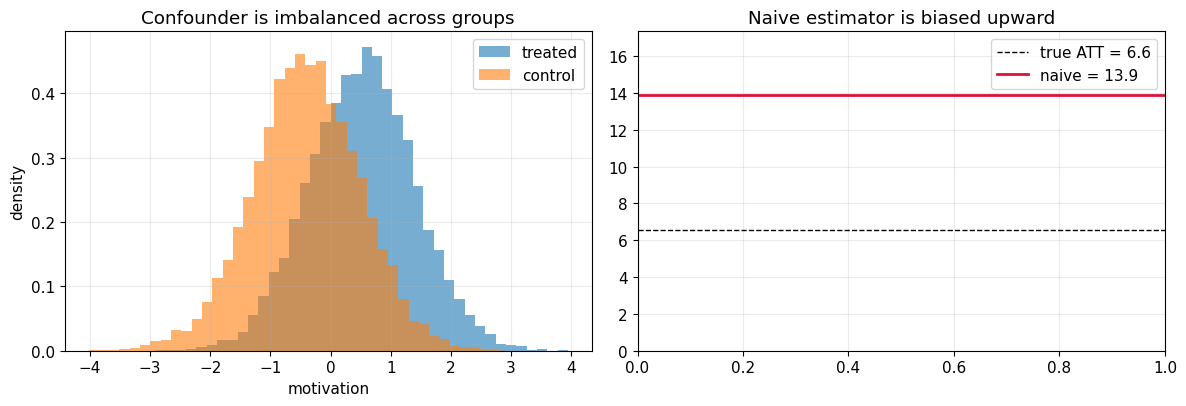

In [5]:
# Visualize the confounding: distributions of the latent confounder differ by group.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].hist(pop["motivation"][T==1], bins=40, alpha=.6, density=True, label="treated")
ax[0].hist(pop["motivation"][T==0], bins=40, alpha=.6, density=True, label="control")
ax[0].set(title="Confounder is imbalanced across groups", xlabel="motivation", ylabel="density")
ax[0].legend()

ax[1].axhline(att, color="k", ls="--", lw=1, label=f"true ATT = {att:.1f}")
ax[1].axhline(naive, color="crimson", ls="-", lw=2, label=f"naive = {naive:.1f}")
ax[1].set(title="Naive estimator is biased upward", ylim=(0, naive*1.25)); ax[1].legend()
plt.tight_layout(); plt.savefig("../figures/w1_confounding.png", dpi=110); plt.show()

## 4. Randomization: the gold standard

A **randomized controlled trial (RCT)** assigns $T_i$ *independently* of the potential
outcomes:

$$ T \perp\!\!\!\perp \big(Y(0), Y(1)\big). $$

Under this independence the selection-bias term vanishes, because
$\mathbb{E}[Y(0)\mid T{=}1]=\mathbb{E}[Y(0)\mid T{=}0]=\mathbb{E}[Y(0)]$. Hence the naive
difference-in-means is **unbiased** for the ATE. Let's prove it empirically by re-running
the *same population* under random assignment.

In [6]:
def assign_random(n, seed=2):
    g = default_rng(seed)
    return (g.uniform(size=n) < 0.5).astype(int)

Tr = assign_random(pop["Y0"].size)
Yr = np.where(Tr == 1, pop["Y1"], pop["Y0"])

rct_est = Yr[Tr==1].mean() - Yr[Tr==0].mean()
rct_bias = pop["Y0"][Tr==1].mean() - pop["Y0"][Tr==0].mean()
print(f"RCT difference-in-means : {rct_est:.3f}")
print(f"True ATE                : {ate:.3f}")
print(f"Residual selection bias : {rct_bias:.4f}   (≈ 0 by randomization)")

RCT difference-in-means : 5.123
True ATE                : 5.014
Residual selection bias : 0.0906   (≈ 0 by randomization)


### Sampling distribution & the analytic standard error

The difference-in-means is a random variable. Its standard error under unequal-variance
(Welch) form is

$$ \widehat{\mathrm{SE}} = \sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_0^2}{n_0}}. $$

We verify this two ways: (a) the analytic SE, and (b) a Monte-Carlo sampling distribution
across many independent randomizations. They must agree.

Analytic SE       : 0.1475
Monte-Carlo SD    : 0.1465
MC mean of est    : 5.0117   (true ATE = 5.0140)


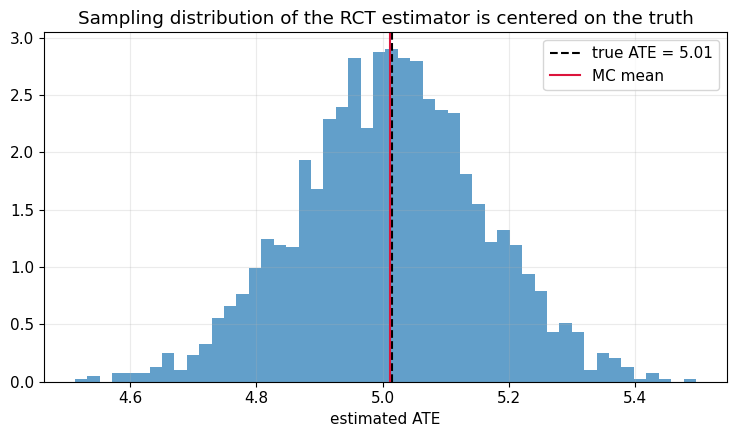

In [7]:
def diff_in_means(Y, T):
    y1, y0 = Y[T==1], Y[T==0]
    est = y1.mean() - y0.mean()
    se = np.sqrt(y1.var(ddof=1)/y1.size + y0.var(ddof=1)/y0.size)
    return est, se

est, se = diff_in_means(Yr, Tr)

# Monte-Carlo: re-randomize the SAME fixed potential outcomes many times.
mc = []
for s in range(2000):
    Tm = assign_random(pop["Y0"].size, seed=1000+s)
    Ym = np.where(Tm==1, pop["Y1"], pop["Y0"])
    mc.append(Ym[Tm==1].mean() - Ym[Tm==0].mean())
mc = np.array(mc)

print(f"Analytic SE       : {se:.4f}")
print(f"Monte-Carlo SD    : {mc.std():.4f}")
print(f"MC mean of est    : {mc.mean():.4f}   (true ATE = {ate:.4f})")

plt.hist(mc, bins=50, density=True, alpha=.7)
plt.axvline(ate, color="k", ls="--", label=f"true ATE = {ate:.2f}")
plt.axvline(mc.mean(), color="crimson", ls="-", label="MC mean")
plt.title("Sampling distribution of the RCT estimator is centered on the truth")
plt.xlabel("estimated ATE"); plt.legend(); plt.tight_layout()
plt.savefig("../figures/w1_sampling.png", dpi=110); plt.show()

## 5. Identification via regression adjustment

Even in an RCT, adjusting for pre-treatment covariates **reduces variance** without
introducing bias. With the linear model $Y = \alpha + \tau T + \beta\,X + \varepsilon$,
the OLS coefficient on $T$ estimates the ATE. We implement OLS from scratch via the normal
equations $\hat\beta = (X^\top X)^{-1}X^\top y$ and confirm the variance reduction.

In [8]:
def ols(X, y):
    X = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = len(y) - X.shape[1]
    sigma2 = resid @ resid / dof
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))
    return beta, se

# Unadjusted (T only) vs covariate-adjusted (T + motivation) on the RCT data.
b_u, se_u = ols(Tr.reshape(-1,1), Yr)
b_a, se_a = ols(np.column_stack([Tr, pop["motivation"]]), Yr)

print(f"Unadjusted  : tau_hat = {b_u[1]:.3f}  (SE {se_u[1]:.3f})")
print(f"Adjusted    : tau_hat = {b_a[1]:.3f}  (SE {se_a[1]:.3f})")
print(f"True ATE    : {ate:.3f}")
print(f"Variance reduction from adjustment: {(1 - (se_a[1]/se_u[1])**2)*100:.1f}%")

Unadjusted  : tau_hat = 5.123  (SE 0.148)
Adjusted    : tau_hat = 5.007  (SE 0.061)
True ATE    : 5.014
Variance reduction from adjustment: 82.9%


## 6. The three identifying assumptions

Everything that follows in this course rests on three assumptions that let observational
data behave *as if* randomized **within strata of covariates** $X$:

1. **Unconfoundedness / Ignorability** — $\big(Y(0),Y(1)\big)\perp\!\!\!\perp T \mid X$.
   All confounders are measured. (Untestable from data — defended by domain knowledge.)
2. **Overlap / Positivity** — $0 < P(T=1\mid X=x) < 1$ for all $x$ in the support.
   Every covariate profile has *some* chance of either treatment. (Checkable.)
3. **SUTVA** — no interference between units, and a single version of treatment.

Under (1)+(2) the ATE is **identified** by the *adjustment formula* / *g-formula*:

$$ \tau_{\text{ATE}} = \mathbb{E}_X\Big[\mathbb{E}[Y\mid T{=}1,X] - \mathbb{E}[Y\mid T{=}0,X]\Big]. $$

We end Week 1 by applying it to the **confounded** observational data and recovering the
truth that the naive estimator missed.

In [9]:
# G-formula via stratified regression on the CONFOUNDED data (T, Y from section 2).
# Fit a flexible-enough outcome model: Y ~ T + motivation + T*motivation.
Xdesign = np.column_stack([T, pop["motivation"], T*pop["motivation"]])
beta, _ = ols(Xdesign, Y)

# Predict both potential outcomes for everyone, then average the difference.
def predict(beta, t):
    X = np.column_stack([np.ones(len(T)), np.full(len(T), t),
                         pop["motivation"], t*pop["motivation"]])
    return X @ beta

mu1 = predict(beta, 1)
mu0 = predict(beta, 0)
g_ate = (mu1 - mu0).mean()

print(f"Naive (biased) estimate : {naive:.3f}")
print(f"G-formula estimate      : {g_ate:.3f}")
print(f"True ATE                : {ate:.3f}")
print()
print("Adjusting for the confounder recovers the causal effect from observational data.")

Naive (biased) estimate : 13.878
G-formula estimate      : 4.869
True ATE                : 5.014

Adjusting for the confounder recovers the causal effect from observational data.


## Summary & what's next

- Causation lives on a **ladder**; prediction only reaches rung 1.
- The **potential-outcomes** framework reframes causal inference as missing data: we never
  see both $Y(1)$ and $Y(0)$ for the same unit.
- Distinguish estimands — **ATE, ATT, ATC** — they differ under heterogeneity + selection.
- The **naive difference-in-means** equals the causal effect *plus* selection bias; we
  derived and numerically verified this decomposition to machine precision.
- **Randomization** zeroes the bias term; we confirmed unbiasedness and matched the
  analytic SE to a Monte-Carlo sampling distribution.
- With **unconfoundedness + overlap + SUTVA**, the **g-formula** identifies the ATE from
  purely observational data — and recovered the truth the naive estimator botched.

**Exercises.** (1) Re-run §3 with a confounder that *suppresses* rather than inflates the
effect; show the naive estimate is now biased downward. (2) Sweep the treated fraction and
plot SE vs. balance. (3) Break positivity (`logits` with slope 6) and watch the g-formula
extrapolate badly — motivation for Week 2.

**Week 2:** we move from algebra to **graphs** — DAGs, $d$-separation, and the back-door
criterion that tells us *which* variables to put in $X$ in the first place.